# Tutorial 2: Effects of Input Correlation (LIF 神經元相關性影響)

本筆記本整理自 Neuromatch Academy - W2D4 Tutorial 2，使用 `brian2` 重現實踐。


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from brian2 import *
from lif_utils import *

# Set simulation preference
prefs.codegen.target = 'numpy'


## 先備知識

共變異: $\text{Cov}(X, Y) = E[(x - \bar{x})(y - \bar{y})] = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{n - 1}$
* $Cov(X, Y) = E[(x - \bar{x})(y - \bar{y})]$ 
* $= E[XY] - E[X \cdot E[Y]] - E[E[X] \cdot Y] + E[E[X] \cdot E[Y]]$
* $= E[XY] - E[Y]E[X] - E[X]E[Y] + E[X]E[Y]$
* $= E[XY] - E[Y]E[X]$ 後續會用到這條


---

* 直覺理解共變異數，假設 $x$, $y$ 同時變大 or 變小，那 $(x_i - \bar{x})(y_i - \bar{y}) > 0$
* 衡量隨機變數間的相關程度
* 缺點: 缺乏單位
    * 假設 $Cov = 5000$ 看起來很大，但假設其實在量身高，而單位是微米呢?

相關性: $Corr(X,Y) = \frac{Cov(X,Y)}{\sigma_X \sigma_Y}$
* $\rho = \frac{Cov(X, Y)}{\sigma_X \sigma_Y} = \frac{E[(X - \mu_X)(Y - \mu_Y)]}{\sigma_X \sigma_Y}$
* 其實就是把共變異數標準化

## Coding Exercise 1A: Compute the correlation

皮爾森相關係數 (Pearson correlation coefficient) 是計算兩時間序列訊號相關程度的核心。


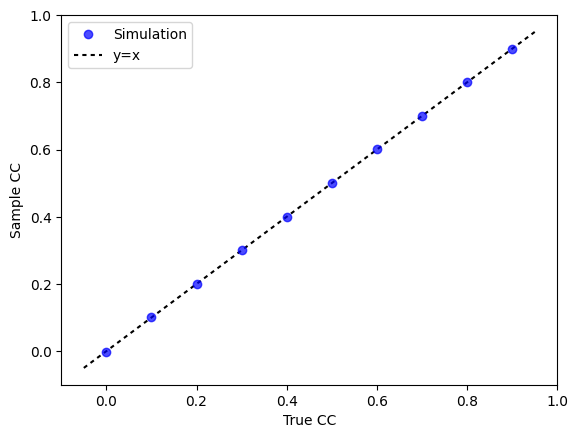

In [2]:
pars = default_pars(T=50000, dt=.1)

c = np.arange(10) * 0.1
r12 = np.zeros(10)
for i in range(10):
	# correlate_input 產生有相關性 GWN 的電流
	I1gL, I2gL = correlate_input(pars, mu=20.0, sig=7.5, c=c[i])
	r12[i] = my_CC(I1gL, I2gL)

plt.figure()
plt.plot(c, r12, 'bo', alpha=0.7, label='Simulation', zorder=2)
plt.plot([-0.05, 0.95], [-0.05, 0.95], 'k--', label='y=x',
		dashes=(2, 2), zorder=1)
plt.xlabel('True CC')
plt.ylabel('Sample CC')
plt.legend(loc='best')
plt.show()



## Coding Exercise 1B: Measure correlation between spike trains

將連續時間點上的 Spike times 藉由時間窗 (binning) 切分為 Spike counts，再進行相關性計算。


## 柏松過程

* 神經元現在會不會發射 Spike，跟它上一秒有沒有發射完全無關，純粹靠擲骰子決定
* 假設你設定的平均放電頻率 $rate = 10Hz$，時間步長 $dt = 0.1ms$。
    * 其實很直覺: $10 次/秒$
    * 對於 $0.1ms$ 是: $10/10000 = 1/1000 次$
        * 實作上就是跑個亂數 $rand < 1/1000 ?$ 是的話就發 spike
        * 可以設定要 $n$ 個時間間隔
    * **可以想像就是產生 $n$ 個 $dt$，每個 $dt$ 都有 1/1000 產生 spike**
        * 甚至可以想成一個函數，只有 $0$ 或是 $1$(spike)
* 變異數等於平均值
    * 發射機率 $p$
    * 期望值 $E = 1 \times p + (1 - p) \times 0 = p$
        * $期望值 = (\text{中獎次數} \times \text{機率}) + (\text{沒中獎次數} \times \text{機率})$
    * 變異數 (距離中心的平方)
        * 中獎: 結果是 1，距離平方 $(1 - p)^2$
        * 沒中: 結果是 0，距離平方 $(0 - p)^2$
        * $Var = p \times (1 - p)^2 + (1 - p) \times p^2$
            * $Var = p \times (1 - p) \times ((1 - p) + p)$ 
            * $Var = p \times (1 - p)$ 由於 $p \approx 0$
            * $Var = p$
    * 這此 $E = Var = p$

In [3]:
rate = 10
dt = 0.01 # 0.01ms
n_samples = 1000000

p = rate * (dt / 1000.0) # 一個 dt 發射頻率

print(f"設定參數: rate={rate} Hz, dt={dt} ms")
print(f"單一步長發射機率 p = {p:.5f}")
print("-" * 30)

# 2. 模擬大量的獨立隨機試驗 (Bernoulli trials)
# 產生 n_samples 個 0 或 1，1 的機率為 p
spikes = (np.random.rand(n_samples) < p).astype(float)

# 3. 計算平均值與變異數
mean_val = np.mean(spikes)
var_val = np.var(spikes)

# 4. 輸出結果
print(f"樣本數: {n_samples}")
print(f"理論期望值 E = p = {p:.5f}")
print(f"樣本平均值 E_sim = {mean_val:.5f}")
print(f"理論變異數 Var = p(1-p) = {p*(1-p):.8f}")
print(f"樣本變異數 Var_sim = {var_val:.8f}")

diff = abs(mean_val - var_val)
print("-" * 30)
print(f"平均值與變異數的差距: {diff:.10f}")

if diff < 1e-4:
    print("\n證明成功：在 p 很小時，E ≈ Var ≈ p。")



設定參數: rate=10 Hz, dt=0.01 ms
單一步長發射機率 p = 0.00010
------------------------------
樣本數: 1000000
理論期望值 E = p = 0.00010
樣本平均值 E_sim = 0.00011
理論變異數 Var = p(1-p) = 0.00009999
樣本變異數 Var_sim = 0.00010599
------------------------------
平均值與變異數的差距: 0.0000000112

證明成功：在 p 很小時，E ≈ Var ≈ p。


## 測量 Spike 的相關性

採用: 母過程抽樣法，Thinning method

目標: 產生兩個神經元 (A 與 B) 的柏松脈衝序列，滿足兩個條件：
1. 兩者的平均放電頻率皆為目標頻率 $r$ (poi_rate)
2. 兩者的皮爾森相關係數剛好等於 $c$ 

母體的 poi_rate: 
* $r_m = \frac{r}{c}$ (放大)，因為 A, B 只抽比例 c 放到相同長度的地方
* 如果 $r_m = r$ 那 A, B 去抽就會變成 poi_rate 是 $r_m \times c$
    * 原本 1 秒有 $r$ 個，但只抽 $c$，可想而知會變成 1 秒剩下 $r \times c$ 個

---

推導為甚麼: $A, B$ 是從母體抽樣出比例 $c$ 的 spike，而 $A, B$ 的相關性就是 $c$

1. $A, B$頻率是 $r$，母體的 spike 頻率是 $\frac{r}{c}$
2. $n$ 是間隔數量，那 $A$ 在 $dt$ 秒觸發機率就是 $r \times dt = \frac{r}{n}$
3. 母體在 $dt$ 秒觸發機率就是則是 $\frac{r}{cn}$
4. 再次提醒:   
    * **可以想像就是產生 $n$ 個 $dt$，每個 $dt$ 都有 1/1000 產生 spike**
        * 甚至可以想成一個函數，只有 $0$ 或是 $1$(spike)

* 推導 $Cov$
    * $A$ 從母體抽中的機率 $c \times \frac{r}{cn} = \frac{r}{n}$，$AB$ 抽重同個 spike 的機率是 $c^2 \times \frac{r}{cn} = \frac{rc}{n}$
    * `spkie(1), no_spike(0)` 期望算出來 = 機率:
        * $E[A] = E[B] = \frac{r}{n}$
        * $E[AB] = \frac{rc}{n}$
        * $Cov(A, B) = E[AB] - E[A]E[B] = \frac{r}{n}(c - \frac{r}{n})$
* 推導 $Var$
    * $Var[A] = E[(A - E[A])^2]$
    * $Var= \frac{r}{n} (1 - \frac{r}{n})^2 + (1 - \frac{r}{n}) \frac{r^2}{n^2} = \frac{r}{n}(1 - \frac{r}{n})$
    * $\sigma_A = \sqrt{\frac{r}{n}(1 - \frac{r}{n})}$
* 推導 $Corr$
    * $\frac{Cov(A, B)}{\sigma_A \sigma_B} = \frac{\frac{r}{n}(c - \frac{r}{n})}{\frac{r}{n}(1 - \frac{r}{n})} = \frac{(c - \frac{r}{n})}{(1 - \frac{r}{n})}$
    * $lim~{n \to \infty}$ 時 $\frac{Cov(A, B)}{\sigma_A \sigma_B} = c$



In [4]:
# Correlated Poisson functions moved to lif_utils.py
poi_rate = 20.
c = 0.2  # set true correlation
pars = default_pars(T=10000)

# bin the spike time
bin_size = 20  # [ms]
my_bin = np.arange(0, pars['T'], bin_size)
n_trials = 100  # 100 realizations

r12 = corr_coeff_pairs(pars, rate=poi_rate, c=c, trials=n_trials, bins=my_bin) # 產生有相關性的 柏松 spike
print(f'True corr coe = {c:.3f}')
print(f'Simu corr coe = {r12.mean():.3f}')

True corr coe = 0.200
Simu corr coe = 0.197


## Section 2: Investigate effect of input correlation on output correlation

這裡實驗輸入具有相關性的 GWN 看 LIF 輸出的 spike 相關性

實驗結果是，雖然輸入輸出正相關，但是 輸入相關性 > 輸出

Simulation time = 0.10 min
Input correlation = 0.8
Output correlation = 0.47563376966558285


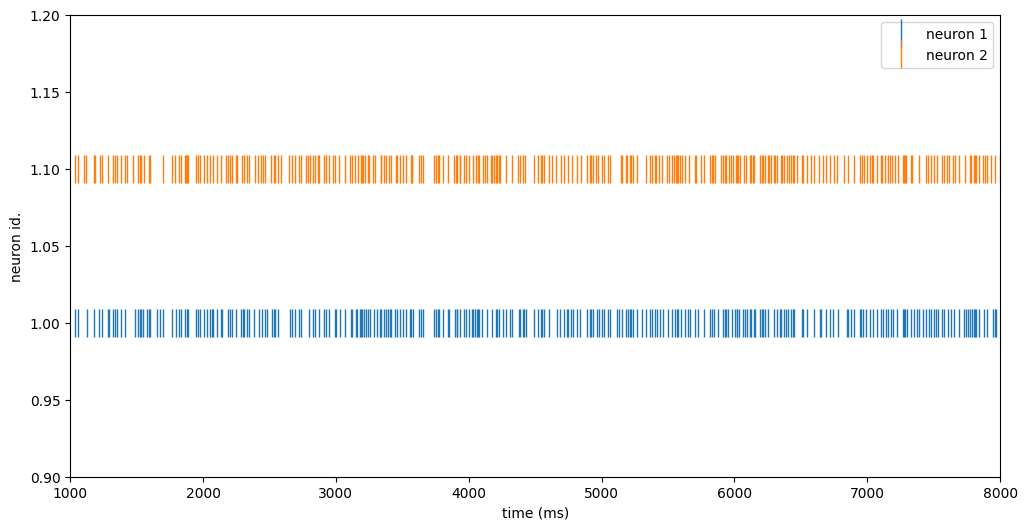

In [11]:
pars = default_pars(T=80000, dt=1.)  # get the parameters
c_in = 0.8  # set input correlation value
gwn_mean = 10.
gwn_std = 10.

bin_size = 10.  # ms
starttime = time.perf_counter()  # time clock
r12_ss, sp_ss, sp1, sp2 = LIF_output_cc(pars, 
                                        mu = gwn_mean, 
                                        sig = gwn_std, 
                                        c = c_in,
                                        bin_size = bin_size, 
                                        n_trials = 10)

# just the time counter
endtime = time.perf_counter()
timecost = (endtime - starttime) / 60.
print(f"Simulation time = {timecost:.2f} min")

print(f"Input correlation = {c_in}")
print(f"Output correlation = {r12_ss}")

plt.figure(figsize=(12, 6))
plt.plot(sp1, np.ones(len(sp1)) * 1, '|', ms=20, label='neuron 1')
plt.plot(sp2, np.ones(len(sp2)) * 1.1, '|', ms=20, label='neuron 2')
plt.xlabel('time (ms)')
plt.ylabel('neuron id.')
plt.xlim(1000, 8000)
plt.ylim(0.9, 1.2)
plt.legend()
plt.show()

這裡把測試不同的輸入相關性，對應到的輸出相關性

Simulation time = 1.03 min


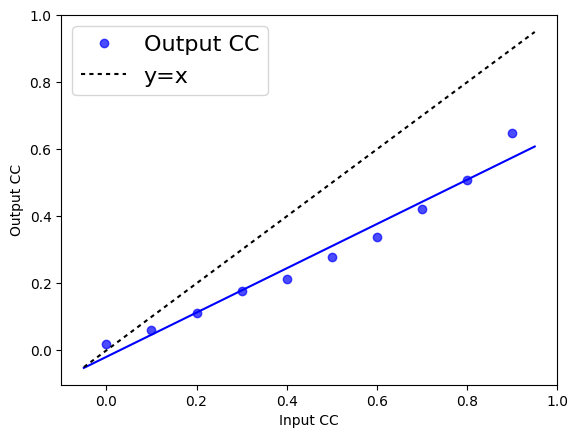

In [ ]:
# @markdown Don't forget to execute this cell!

# 會跑非常久

if True:
	pars = default_pars(T=80000, dt=1.)  # get the parameters
	bin_size = 10.
	c_in = np.arange(0, 1.0, 0.1)  # set the range for input CC
	r12_ss = np.zeros(len(c_in))  # small mu, small sigma

	starttime = time.perf_counter() # time clock
	for ic in range(len(c_in)):
		r12_ss[ic], sp_ss, sp1, sp2 = LIF_output_cc(pars, 
													mu = 10.0, 
													sig = 20.,
													c = c_in[ic], 
													bin_size = bin_size,
													n_trials = 10)

	endtime = time.perf_counter()
	timecost = (endtime - starttime) / 60.
	print(f"Simulation time = {timecost:.2f} min")

	plot_c_r_LIF(c_in, r12_ss, mycolor='b', mylabel='Output CC')
	plt.plot([c_in.min() - 0.05, c_in.max() + 0.05],
			[c_in.min() - 0.05, c_in.max() + 0.05],
			'k--', dashes=(2, 2), label='y=x')

	plt.xlabel('Input CC')
	plt.ylabel('Output CC')
	plt.legend(loc='best', fontsize=16)
	plt.show()

## Section 3: Correlation transfer function

改變背景高斯白噪音的平均值 $\mu$ 與變異數 $\sigma$，以此模擬不同輸入發放頻率 (Input Rate) 造成的影響。


Simulation time = 1.42 min


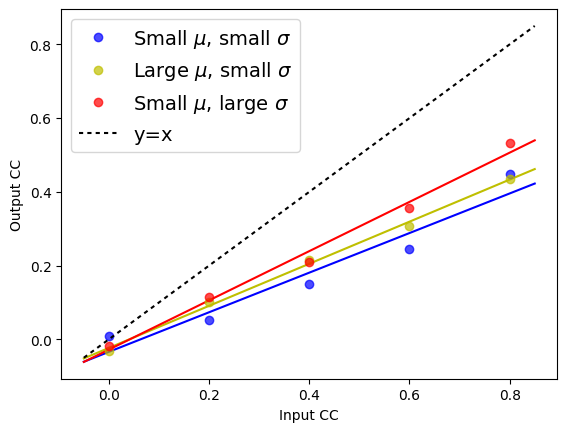

In [14]:
# @markdown Execute this cell to visualize correlation transfer functions

pars = default_pars(T=80000, dt=1.) # get the parameters
n_trials = 10
bin_size = 10.
c_in = np.arange(0., 1., 0.2)  # set the range for input CC
r12_ss = np.zeros(len(c_in))   # small mu, small sigma
r12_ls = np.zeros(len(c_in))   # large mu, small sigma
r12_sl = np.zeros(len(c_in))   # small mu, large sigma

starttime = time.perf_counter()  # time clock
for ic in range(len(c_in)):
  r12_ss[ic], sp_ss, sp1, sp2 = LIF_output_cc(pars, mu=10.0, sig=10.,
                                              c=c_in[ic], bin_size=bin_size,
                                              n_trials=n_trials)
  r12_ls[ic], sp_ls, sp1, sp2 = LIF_output_cc(pars, mu=18.0, sig=10.,
                                              c=c_in[ic], bin_size=bin_size,
                                              n_trials=n_trials)
  r12_sl[ic], sp_sl, sp1, sp2 = LIF_output_cc(pars, mu=10.0, sig=20.,
                                              c=c_in[ic], bin_size=bin_size,
                                              n_trials=n_trials)
endtime = time.perf_counter()
timecost = (endtime - starttime) / 60.
print(f"Simulation time = {timecost:.2f} min")


plot_c_r_LIF(c_in, r12_ss, mycolor='b', mylabel=r'Small $\mu$, small $\sigma$')
plot_c_r_LIF(c_in, r12_ls, mycolor='y', mylabel=r'Large $\mu$, small $\sigma$')
plot_c_r_LIF(c_in, r12_sl, mycolor='r', mylabel=r'Small $\mu$, large $\sigma$')
plt.plot([c_in.min() - 0.05, c_in.max() + 0.05],
         [c_in.min() - 0.05, c_in.max() + 0.05],
         'k--', dashes=(2, 2), label='y=x')
plt.xlabel('Input CC')
plt.ylabel('Output CC')
plt.legend(loc='best', fontsize=14)
plt.show()